# Coalescent exponential growth rate prior

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import laplace, norm, gamma
import seaborn as sns

## Laplace prior

### Default

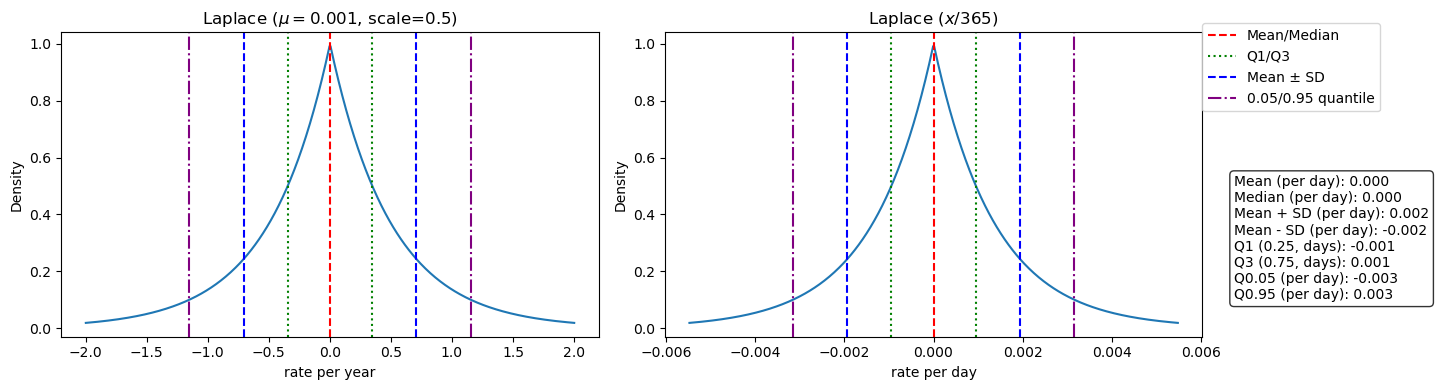

In [2]:
mu = 0.001
scale = 0.5
x = np.linspace(mu - 4*scale, mu + 4*scale, 500)
y = laplace.pdf(x, loc=mu, scale=scale)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mean = mu
std = scale * np.sqrt(2)
q1 = laplace.ppf(0.25, loc=mu, scale=scale)
q3 = laplace.ppf(0.75, loc=mu, scale=scale)
q05 = laplace.ppf(0.05, loc=mu, scale=scale)
q95 = laplace.ppf(0.95, loc=mu, scale=scale)

# Original scale
sns.lineplot(x=x, y=y, ax=axes[0])
axes[0].set_title(f"Laplace ($\\mu={mu}$, scale={scale})")
axes[0].set_xlabel("rate per year")
axes[0].set_ylabel("Density")
axes[0].axvline(mean, color="red", linestyle="--", label="Mean/Median")
axes[0].axvline(q1, color="green", linestyle=":", label="Q1/Q3")
axes[0].axvline(q3, color="green", linestyle=":", label=None)
axes[0].axvline(mean - std, color="blue", linestyle="--", label="Mean ± SD")
axes[0].axvline(mean + std, color="blue", linestyle="--", label=None)
axes[0].axvline(q05, color="purple", linestyle="-.", label="0.05/0.95 quantile")
axes[0].axvline(q95, color="purple", linestyle="-.", label=None)

# x divided by 365
sns.lineplot(x=x / 365, y=y, ax=axes[1])
axes[1].set_title("Laplace ($x / 365$)")
axes[1].set_xlabel("rate per day")
axes[1].set_ylabel("Density")
axes[1].axvline(mean / 365, color="red", linestyle="--")
axes[1].axvline(q1 / 365, color="green", linestyle=":")
axes[1].axvline(q3 / 365, color="green", linestyle=":")
axes[1].axvline((mean - std) / 365, color="blue", linestyle="--")
axes[1].axvline((mean + std) / 365, color="blue", linestyle="--")
axes[1].axvline(q05 / 365, color="purple", linestyle="-.")
axes[1].axvline(q95 / 365, color="purple", linestyle="-.")

# Place one legend to the right of both plots
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.885), borderaxespad=0.)

# Prepare statistics text
stats_text = (
    f"Mean (per day): {mean/365:.3f}\n"
    f"Median (per day): {mean/365:.3f}\n"
    f"Mean + SD (per day): {(mean + std)/365:.3f}\n"
    f"Mean - SD (per day): {(mean - std)/365:.3f}\n"
    f"Q1 (0.25, days): {q1/365:.3f}\n"
    f"Q3 (0.75, days): {q3/365:.3f}\n"
    f"Q0.05 (per day): {q05/365:.3f}\n"
    f"Q0.95 (per day): {q95/365:.3f}"
)


# Add text box under the legend, outside the plotting window
fig.text(
    0.885, 0.55, stats_text,  # Adjust x (0.87) and y (0.25) as needed
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()
fig.savefig("default_growth_prior.png", bbox_inches="tight")

### Proposed:

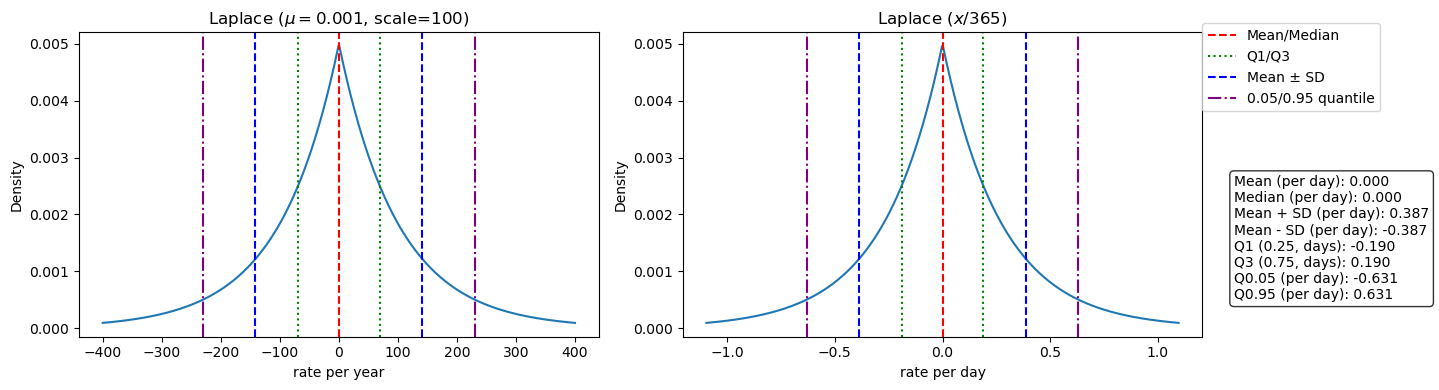

In [3]:
mu = 0.001
scale = 100
x = np.linspace(mu - 4*scale, mu + 4*scale, 500)
y = laplace.pdf(x, loc=mu, scale=scale)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mean = mu
std = scale * np.sqrt(2)
q1 = laplace.ppf(0.25, loc=mu, scale=scale)
q3 = laplace.ppf(0.75, loc=mu, scale=scale)
q05 = laplace.ppf(0.05, loc=mu, scale=scale)
q95 = laplace.ppf(0.95, loc=mu, scale=scale)

# Original scale
sns.lineplot(x=x, y=y, ax=axes[0])
axes[0].set_title(f"Laplace ($\\mu={mu}$, scale={scale})")
axes[0].set_xlabel("rate per year")
axes[0].set_ylabel("Density")
axes[0].axvline(mean, color="red", linestyle="--", label="Mean/Median")
axes[0].axvline(q1, color="green", linestyle=":", label="Q1/Q3")
axes[0].axvline(q3, color="green", linestyle=":", label=None)
axes[0].axvline(mean - std, color="blue", linestyle="--", label="Mean ± SD")
axes[0].axvline(mean + std, color="blue", linestyle="--", label=None)
axes[0].axvline(q05, color="purple", linestyle="-.", label="0.05/0.95 quantile")
axes[0].axvline(q95, color="purple", linestyle="-.", label=None)

# x divided by 365
sns.lineplot(x=x / 365, y=y, ax=axes[1])
axes[1].set_title("Laplace ($x / 365$)")
axes[1].set_xlabel("rate per day")
axes[1].set_ylabel("Density")
axes[1].axvline(mean / 365, color="red", linestyle="--")
axes[1].axvline(q1 / 365, color="green", linestyle=":")
axes[1].axvline(q3 / 365, color="green", linestyle=":")
axes[1].axvline((mean - std) / 365, color="blue", linestyle="--")
axes[1].axvline((mean + std) / 365, color="blue", linestyle="--")
axes[1].axvline(q05 / 365, color="purple", linestyle="-.")
axes[1].axvline(q95 / 365, color="purple", linestyle="-.")

# Place one legend to the right of both plots
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.885), borderaxespad=0.)

# Prepare statistics text
stats_text = (
    f"Mean (per day): {mean/365:.3f}\n"
    f"Median (per day): {mean/365:.3f}\n"
    f"Mean + SD (per day): {(mean + std)/365:.3f}\n"
    f"Mean - SD (per day): {(mean - std)/365:.3f}\n"
    f"Q1 (0.25, days): {q1/365:.3f}\n"
    f"Q3 (0.75, days): {q3/365:.3f}\n"
    f"Q0.05 (per day): {q05/365:.3f}\n"
    f"Q0.95 (per day): {q95/365:.3f}"
)


# Add text box under the legend, outside the plotting window
fig.text(
    0.885, 0.55, stats_text,  # Adjust x (0.87) and y (0.25) as needed
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()
fig.savefig("laplace_upscaled_growth_prior.png", bbox_inches="tight")

## Normal distribution

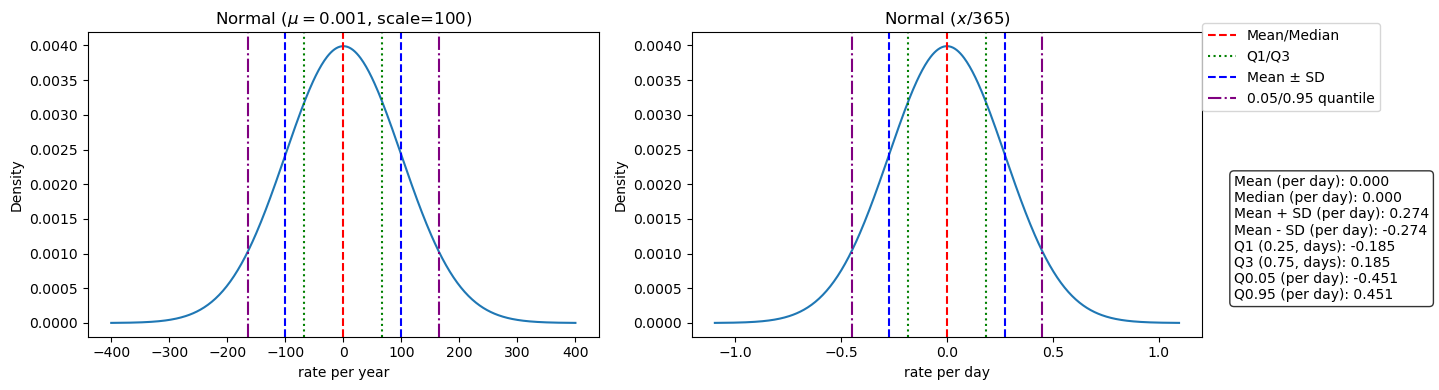

In [4]:
mu = 0.001
scale = 100
x = np.linspace(mu - 4*scale, mu + 4*scale, 500)
y = norm.pdf(x, loc=mu, scale=scale)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mean = mu
std = scale
q1 = norm.ppf(0.25, loc=mu, scale=scale)
q3 = norm.ppf(0.75, loc=mu, scale=scale)
q05 = norm.ppf(0.05, loc=mu, scale=scale)
q95 = norm.ppf(0.95, loc=mu, scale=scale)

# Original scale
sns.lineplot(x=x, y=y, ax=axes[0])
axes[0].set_title(f"Normal ($\\mu={mu}$, scale={scale})")
axes[0].set_xlabel("rate per year")
axes[0].set_ylabel("Density")
axes[0].axvline(mean, color="red", linestyle="--", label="Mean/Median")
axes[0].axvline(q1, color="green", linestyle=":", label="Q1/Q3")
axes[0].axvline(q3, color="green", linestyle=":", label=None)
axes[0].axvline(mean - std, color="blue", linestyle="--", label="Mean ± SD")
axes[0].axvline(mean + std, color="blue", linestyle="--", label=None)
axes[0].axvline(q05, color="purple", linestyle="-.", label="0.05/0.95 quantile")
axes[0].axvline(q95, color="purple", linestyle="-.", label=None)

# x divided by 365
sns.lineplot(x=x / 365, y=y, ax=axes[1])
axes[1].set_title("Normal ($x / 365$)")
axes[1].set_xlabel("rate per day")
axes[1].set_ylabel("Density")
axes[1].axvline(mean / 365, color="red", linestyle="--")
axes[1].axvline(q1 / 365, color="green", linestyle=":")
axes[1].axvline(q3 / 365, color="green", linestyle=":")
axes[1].axvline((mean - std) / 365, color="blue", linestyle="--")
axes[1].axvline((mean + std) / 365, color="blue", linestyle="--")
axes[1].axvline(q05 / 365, color="purple", linestyle="-.")
axes[1].axvline(q95 / 365, color="purple", linestyle="-.")

# Place one legend to the right of both plots
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.885), borderaxespad=0.)

# Prepare statistics text
stats_text = (
    f"Mean (per day): {mean/365:.3f}\n"
    f"Median (per day): {mean/365:.3f}\n"
    f"Mean + SD (per day): {(mean + std)/365:.3f}\n"
    f"Mean - SD (per day): {(mean - std)/365:.3f}\n"
    f"Q1 (0.25, days): {q1/365:.3f}\n"
    f"Q3 (0.75, days): {q3/365:.3f}\n"
    f"Q0.05 (per day): {q05/365:.3f}\n"
    f"Q0.95 (per day): {q95/365:.3f}"
)

# Add text box under the legend, outside the plotting window
fig.text(
    0.885, 0.55, stats_text,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()

## Gamma Distribution

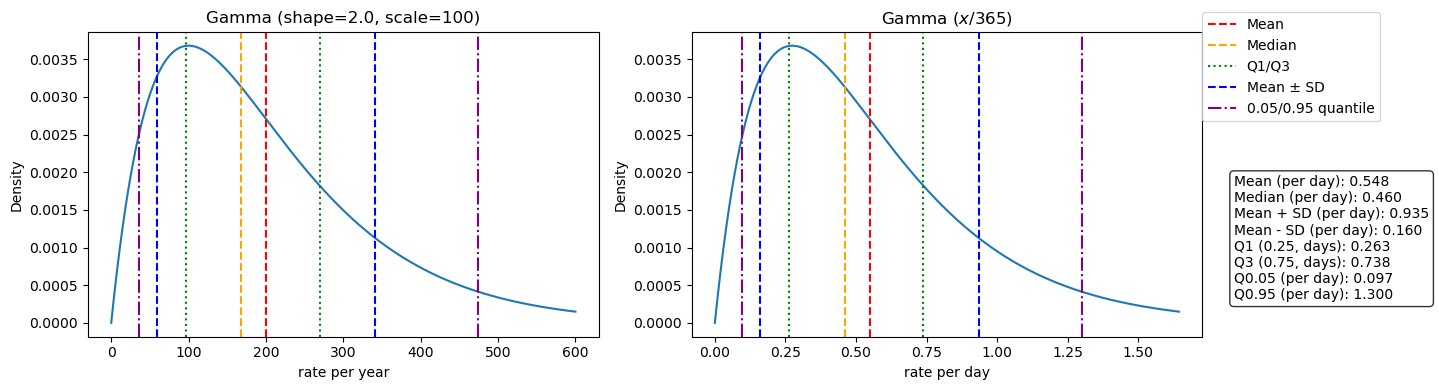

In [5]:
shape = 2.0      # k (also called a)
scale = 100    # theta (mean = k*theta)
mu = shape * scale

x = np.linspace(0, mu + 4*scale, 500)
y = gamma.pdf(x, a=shape, scale=scale)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mean = gamma.mean(a=shape, scale=scale)
std = gamma.std(a=shape, scale=scale)
median = gamma.median(a=shape, scale=scale)
q1 = gamma.ppf(0.25, a=shape, scale=scale)
q3 = gamma.ppf(0.75, a=shape, scale=scale)
q05 = gamma.ppf(0.05, a=shape, scale=scale)
q95 = gamma.ppf(0.95, a=shape, scale=scale)

# Original scale
sns.lineplot(x=x, y=y, ax=axes[0])
axes[0].set_title(f"Gamma (shape={shape}, scale={scale})")
axes[0].set_xlabel("rate per year")
axes[0].set_ylabel("Density")
axes[0].axvline(mean, color="red", linestyle="--", label="Mean")
axes[0].axvline(median, color="orange", linestyle="--", label="Median")
axes[0].axvline(q1, color="green", linestyle=":", label="Q1/Q3")
axes[0].axvline(q3, color="green", linestyle=":", label=None)
axes[0].axvline(mean - std, color="blue", linestyle="--", label="Mean ± SD")
axes[0].axvline(mean + std, color="blue", linestyle="--", label=None)
axes[0].axvline(q05, color="purple", linestyle="-.", label="0.05/0.95 quantile")
axes[0].axvline(q95, color="purple", linestyle="-.", label=None)

# x divided by 365
sns.lineplot(x=x / 365, y=y, ax=axes[1])
axes[1].set_title("Gamma ($x / 365$)")
axes[1].set_xlabel("rate per day")
axes[1].set_ylabel("Density")
axes[1].axvline(mean / 365, color="red", linestyle="--")
axes[1].axvline(median / 365, color="orange", linestyle="--")
axes[1].axvline(q1 / 365, color="green", linestyle=":")
axes[1].axvline(q3 / 365, color="green", linestyle=":")
axes[1].axvline((mean - std) / 365, color="blue", linestyle="--")
axes[1].axvline((mean + std) / 365, color="blue", linestyle="--")
axes[1].axvline(q05 / 365, color="purple", linestyle="-.")
axes[1].axvline(q95 / 365, color="purple", linestyle="-.")

# Place one legend to the right of both plots
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.885), borderaxespad=0.)

# Prepare statistics text (all in days)
stats_text = (
    f"Mean (per day): {mean/365:.3f}\n"
    f"Median (per day): {median/365:.3f}\n"
    f"Mean + SD (per day): {(mean + std)/365:.3f}\n"
    f"Mean - SD (per day): {(mean - std)/365:.3f}\n"
    f"Q1 (0.25, days): {q1/365:.3f}\n"
    f"Q3 (0.75, days): {q3/365:.3f}\n"
    f"Q0.05 (per day): {q05/365:.3f}\n"
    f"Q0.95 (per day): {q95/365:.3f}"
)

# Add text box under the legend, outside the plotting window
fig.text(
    0.885, 0.55, stats_text,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.tight_layout()
plt.show()